# 08 — Final Comparison

Run notebooks `01` through `07` first. This notebook reads the result files
from the active `RUN_MODE` (`results/smoke/` or `results/final/`) and creates
the combined tables and plots.


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "utils").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils.config import (
    ROOT,
    DATASETS,
    CLASSIFIERS,
    RESULTS_DIR,
    PLOTS_DIR,
)
from utils.preprocessing import load_processed_data

PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and verify all result files


In [2]:
result_files = [
    "baseline_results.csv",
    "ga_results.csv",
    "pso_results.csv",
    "gwo_results.csv",
    "woa_results.csv",
    "csa_results.csv",
]

missing_files = [
    filename
    for filename in result_files
    if not (RESULTS_DIR / filename).exists()
]

if missing_files:
    raise FileNotFoundError(
        "Run the missing notebooks first. Missing result files: "
        + ", ".join(missing_files)
    )

frames = [
    pd.read_csv(RESULTS_DIR / filename)
    for filename in result_files
]

all_results = pd.concat(frames, ignore_index=True)

all_results["TotalRuntime"] = (
    all_results["SelectionRuntime"].fillna(0)
    + all_results["TestRuntime"].fillna(0)
)

print("Loaded rows:", len(all_results))
print(all_results.groupby("Algorithm").size())
all_results.head()


Loaded rows: 36
Algorithm
Baseline    6
CSA         6
GA          6
GWO         6
PSO         6
WOA         6
dtype: int64


,Dataset,Classifier,Algorithm,Seed,ValidationFitness,Accuracy,Precision,Recall,F1,ROC_AUC,Features,SelectionRuntime,TestRuntime,SelectedFeatureNames,MaskFile,ConvergenceFile,TotalRuntime
0,breast,svm,Baseline,42,NaN,0.982456,1.000000,0.952381,0.975610,0.995370,30,0.0,0.010912,"[""radius_mean"", ""texture_mean"", ""perimeter_mea...",NaN,NaN,0.010912
1,breast,random_forest,Baseline,42,NaN,0.973684,0.975610,0.952381,0.963855,0.994874,30,0.0,0.284422,"[""radius_mean"", ""texture_mean"", ""perimeter_mea...",NaN,NaN,0.284422
2,breast,xgboost,Baseline,42,NaN,0.973684,0.975610,0.952381,0.963855,0.997685,30,0.0,0.098015,"[""radius_mean"", ""texture_mean"", ""perimeter_mea...",NaN,NaN,0.098015
3,heart,svm,Baseline,42,NaN,0.793478,0.820000,0.803922,0.811881,0.885820,25,0.0,0.025737,"[""age"", ""trestbps"", ""chol"", ""thalch"", ""oldpeak...",NaN,NaN,0.025737
4,heart,random_forest,Baseline,42,NaN,0.815217,0.861702,0.794118,0.826531,0.882174,25,0.0,0.314486,"[""age"", ""trestbps"", ""chol"", ""thalch"", ""oldpeak...",NaN,NaN,0.314486


## 2. Mean ± standard-deviation summary


In [3]:
summary = (
    all_results
    .groupby(["Dataset", "Classifier", "Algorithm"])
    .agg(
        Runs=("Accuracy", "count"),
        AccuracyMean=("Accuracy", "mean"),
        AccuracyStd=("Accuracy", "std"),
        PrecisionMean=("Precision", "mean"),
        PrecisionStd=("Precision", "std"),
        RecallMean=("Recall", "mean"),
        RecallStd=("Recall", "std"),
        F1Mean=("F1", "mean"),
        F1Std=("F1", "std"),
        AUCMean=("ROC_AUC", "mean"),
        AUCStd=("ROC_AUC", "std"),
        FeaturesMean=("Features", "mean"),
        FeaturesStd=("Features", "std"),
        RuntimeMean=("TotalRuntime", "mean"),
        RuntimeStd=("TotalRuntime", "std"),
    )
    .reset_index()
)

summary.to_csv(
    RESULTS_DIR / "comparison_summary.csv",
    index=False,
)

summary


,Dataset,Classifier,Algorithm,Runs,AccuracyMean,AccuracyStd,PrecisionMean,PrecisionStd,RecallMean,RecallStd,F1Mean,F1Std,AUCMean,AUCStd,FeaturesMean,FeaturesStd,RuntimeMean,RuntimeStd
0,breast,random_forest,Baseline,1,0.973684,NaN,0.975610,NaN,0.952381,NaN,0.963855,NaN,0.994874,NaN,30.0,NaN,0.284422,NaN
1,breast,random_forest,CSA,1,0.982456,NaN,1.000000,NaN,0.952381,NaN,0.975610,NaN,0.998347,NaN,15.0,NaN,5.732784,NaN
2,breast,random_forest,GA,1,0.982456,NaN,1.000000,NaN,0.952381,NaN,0.975610,NaN,0.998347,NaN,15.0,NaN,4.267845,NaN
3,breast,random_forest,GWO,1,0.982456,NaN,1.000000,NaN,0.952381,NaN,0.975610,NaN,0.998347,NaN,15.0,NaN,5.717014,NaN
4,breast,random_forest,PSO,1,0.982456,NaN,1.000000,NaN,0.952381,NaN,0.975610,NaN,0.998347,NaN,15.0,NaN,5.598558,NaN
5,breast,random_forest,WOA,1,0.982456,NaN,1.000000,NaN,0.952381,NaN,0.975610,NaN,0.998347,NaN,15.0,NaN,5.683982,NaN
6,breast,svm,Baseline,1,0.982456,NaN,1.000000,NaN,0.952381,NaN,0.975610,NaN,0.995370,NaN,30.0,NaN,0.010912,NaN
7,breast,svm,CSA,1,0.973684,NaN,0.975610,NaN,0.952381,NaN,0.963855,NaN,0.991402,NaN,16.0,NaN,0.215682,NaN
8,breast,svm,GA,1,0.973684,NaN,1.000000,NaN,0.928571,NaN,0.962963,NaN,0.994709,NaN,15.0,NaN,0.189687,NaN
9,breast,svm,GWO,1,0.964912,NaN,0.975000,NaN,0.928571,NaN,0.951220,NaN,0.989749,NaN,17.0,NaN,0.221748,NaN


## 3. Accuracy and F1-score


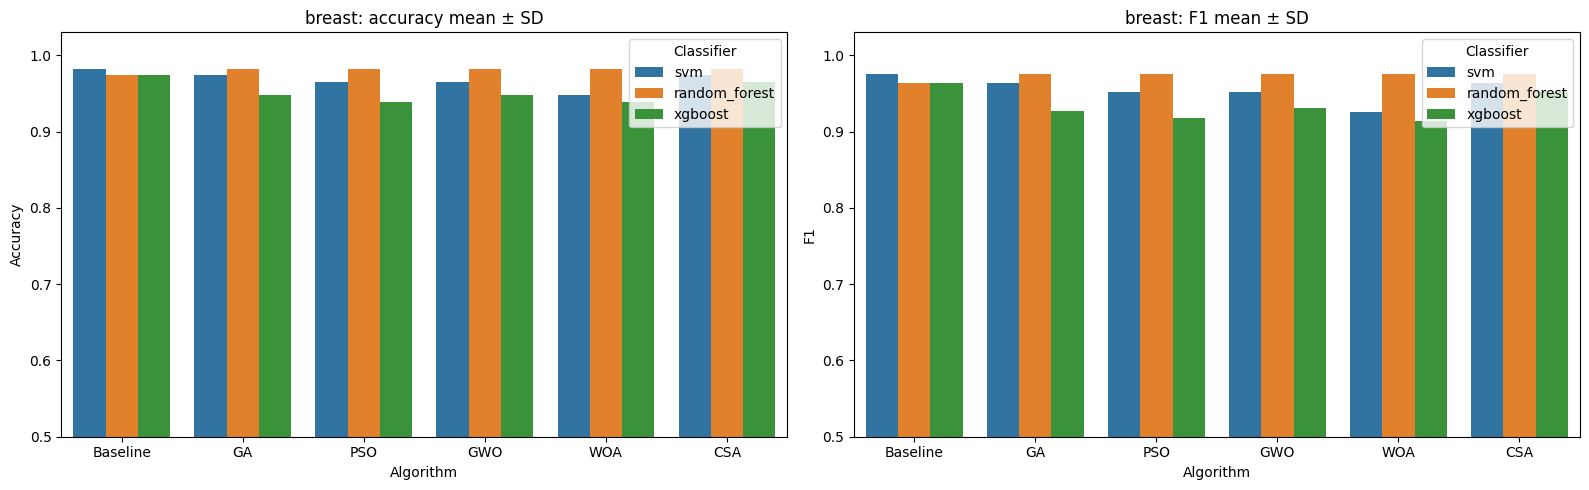

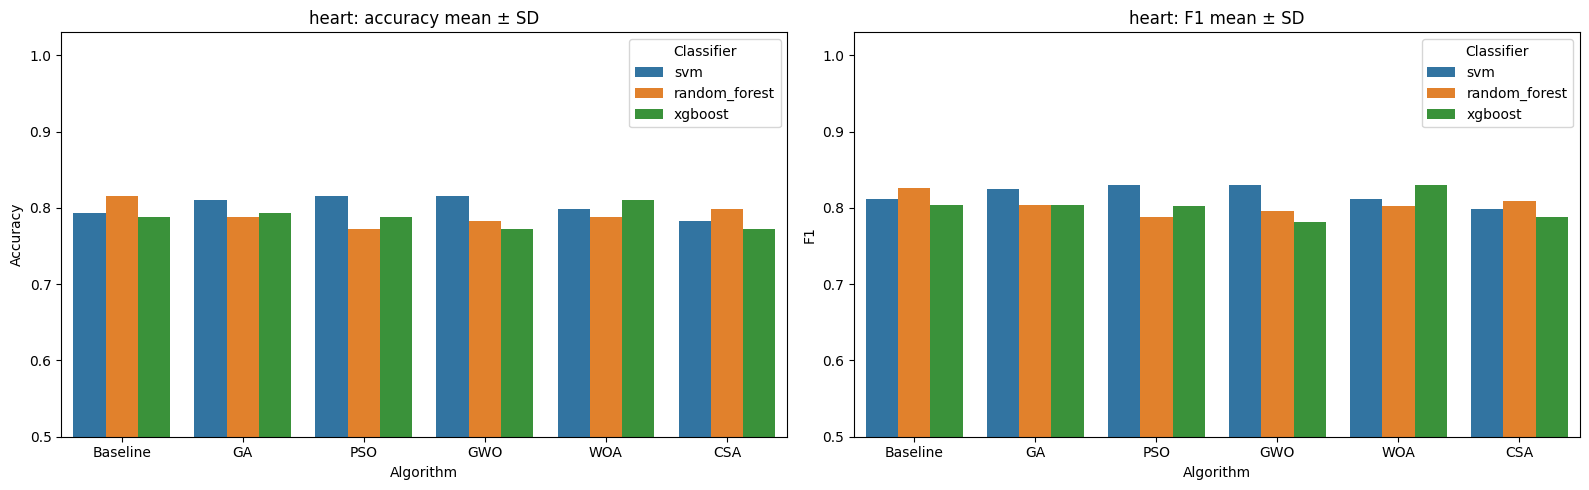

In [4]:
for dataset_name in DATASETS:
    subset = all_results[
        all_results["Dataset"] == dataset_name
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(
        data=subset,
        x="Algorithm",
        y="Accuracy",
        hue="Classifier",
        errorbar="sd",
        ax=axes[0],
    )
    axes[0].set_ylim(0.5, 1.03)
    axes[0].set_title(
        f"{dataset_name}: accuracy mean ± SD"
    )

    sns.barplot(
        data=subset,
        x="Algorithm",
        y="F1",
        hue="Classifier",
        errorbar="sd",
        ax=axes[1],
    )
    axes[1].set_ylim(0.5, 1.03)
    axes[1].set_title(
        f"{dataset_name}: F1 mean ± SD"
    )

    plt.tight_layout()
    plt.savefig(
        PLOTS_DIR / f"{dataset_name}_accuracy_f1.png",
        dpi=150,
    )
    plt.show()


## 4. Selected-feature count and runtime


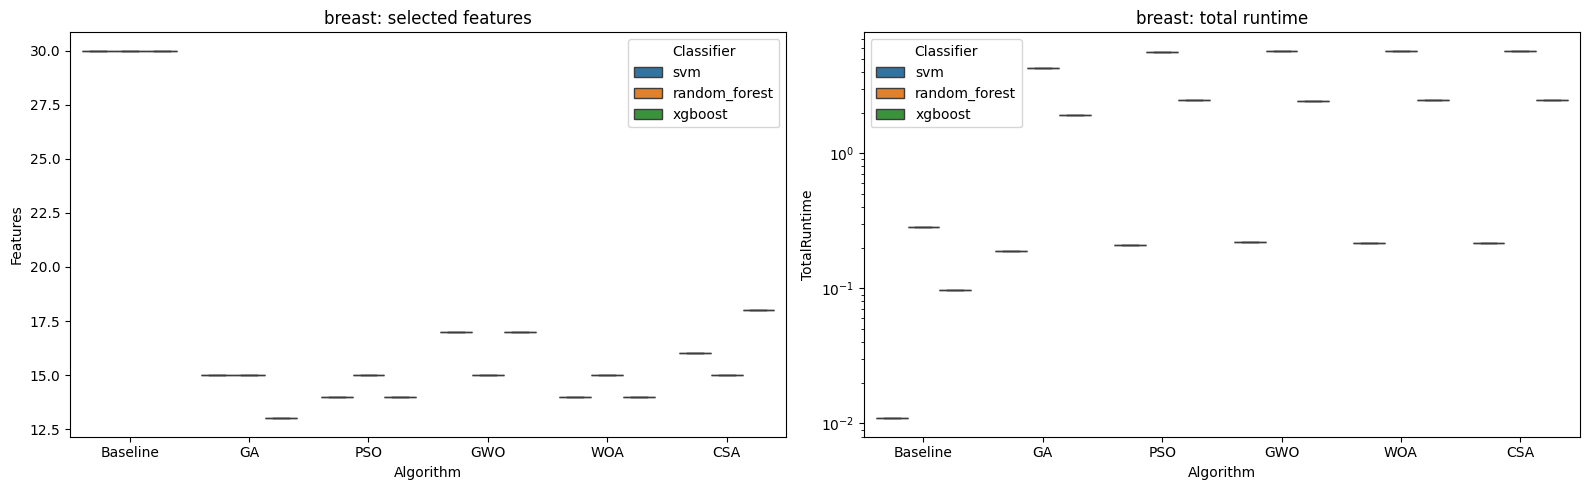

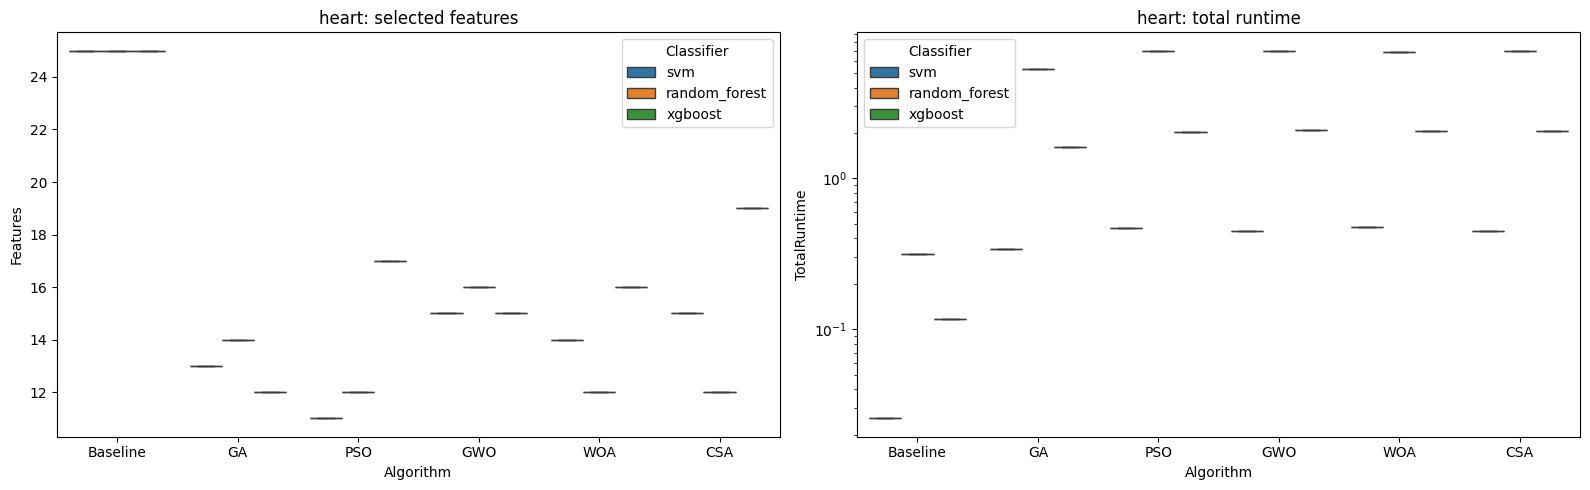

In [5]:
for dataset_name in DATASETS:
    subset = all_results[
        all_results["Dataset"] == dataset_name
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.boxplot(
        data=subset,
        x="Algorithm",
        y="Features",
        hue="Classifier",
        ax=axes[0],
    )
    axes[0].set_title(
        f"{dataset_name}: selected features"
    )

    sns.boxplot(
        data=subset,
        x="Algorithm",
        y="TotalRuntime",
        hue="Classifier",
        ax=axes[1],
    )
    axes[1].set_yscale("log")
    axes[1].set_title(
        f"{dataset_name}: total runtime"
    )

    plt.tight_layout()
    plt.savefig(
        PLOTS_DIR / f"{dataset_name}_features_runtime.png",
        dpi=150,
    )
    plt.show()


## 5. Mean convergence with SD shading


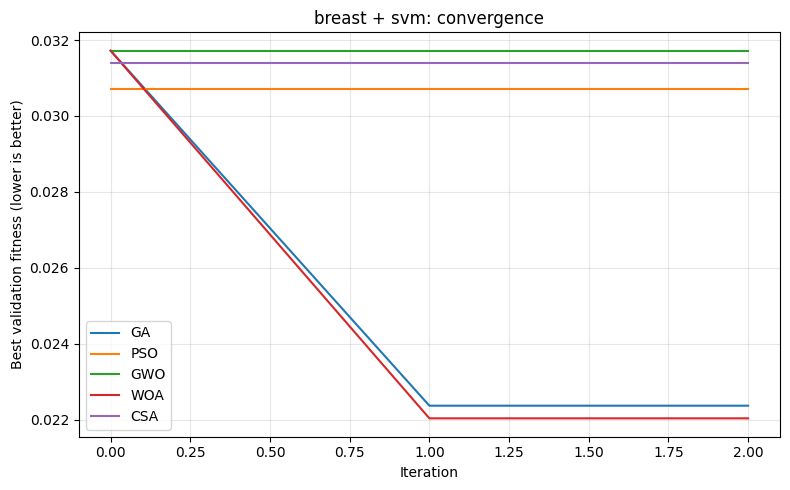

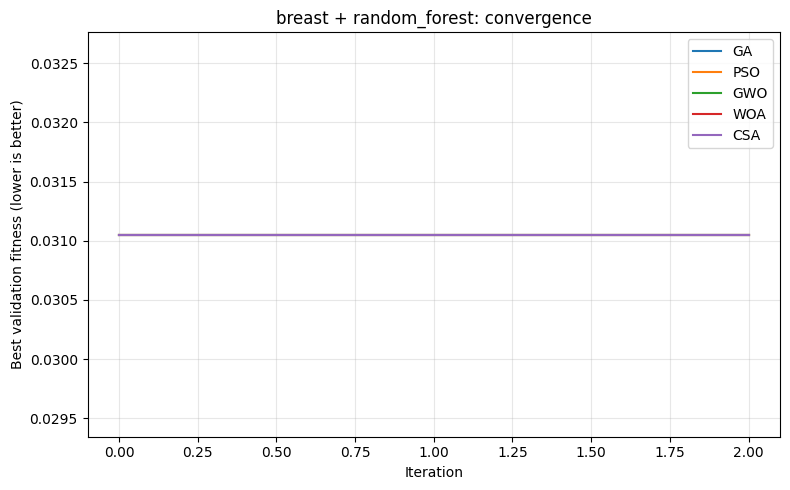

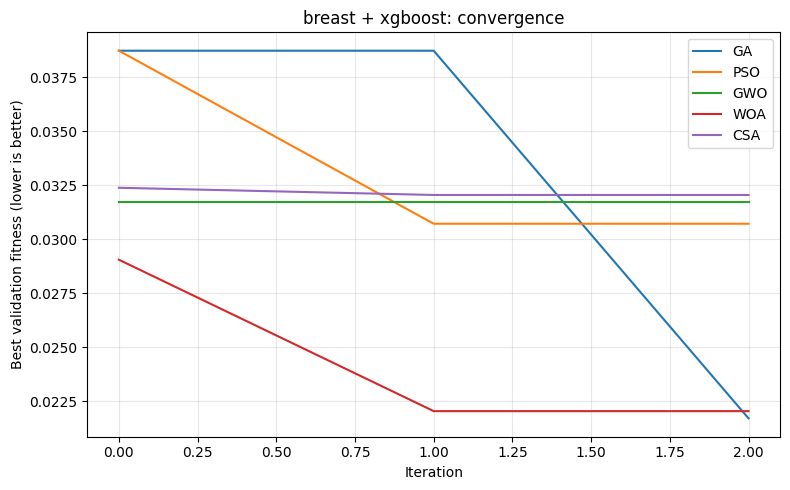

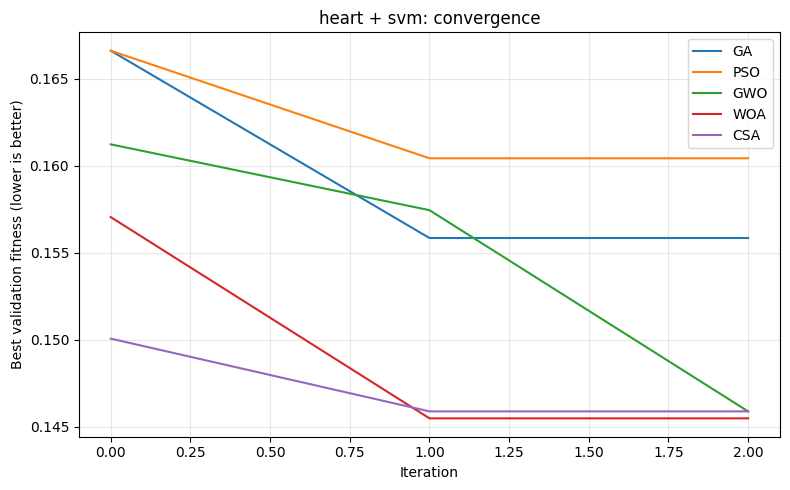

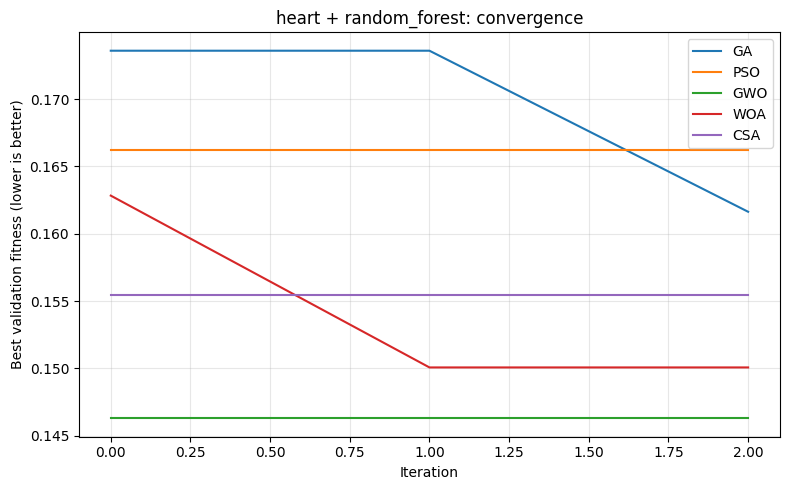

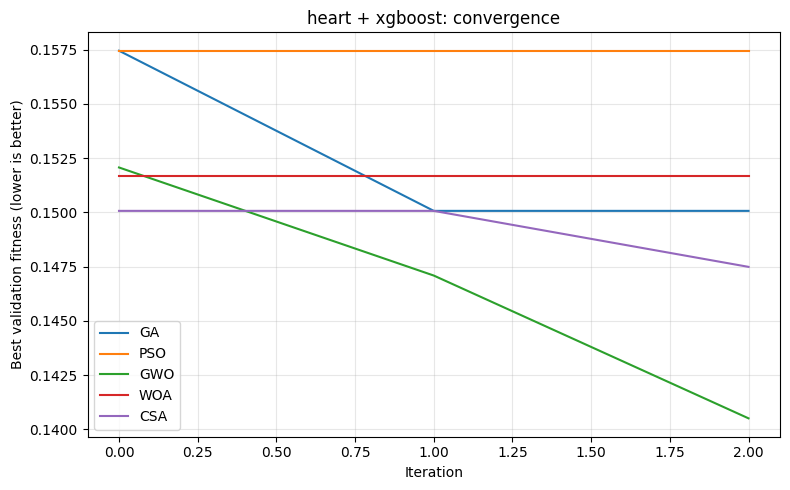

In [6]:
optimizer_names = ["GA", "PSO", "GWO", "WOA", "CSA"]

for dataset_name in DATASETS:
    for classifier_name in CLASSIFIERS:
        plt.figure(figsize=(8, 5))

        for algorithm_name in optimizer_names:
            rows = all_results[
                (all_results["Dataset"] == dataset_name)
                & (
                    all_results["Classifier"]
                    == classifier_name
                )
                & (
                    all_results["Algorithm"]
                    == algorithm_name
                )
            ]

            curves = []

            for path_string in rows[
                "ConvergenceFile"
            ].dropna():
                path = ROOT / path_string

                if path.exists():
                    curves.append(np.load(path))

            if not curves:
                continue

            curves = np.vstack(curves)

            mean_curve = curves.mean(axis=0)
            std_curve = curves.std(axis=0)
            x = np.arange(len(mean_curve))

            plt.plot(
                x,
                mean_curve,
                label=algorithm_name,
            )
            plt.fill_between(
                x,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.15,
            )

        plt.xlabel("Iteration")
        plt.ylabel(
            "Best validation fitness (lower is better)"
        )
        plt.title(
            f"{dataset_name} + "
            f"{classifier_name}: convergence"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(
            PLOTS_DIR
            / (
                f"{dataset_name}_"
                f"{classifier_name}_convergence.png"
            ),
            dpi=150,
        )
        plt.show()


## 6. Feature-selection frequency across seeds


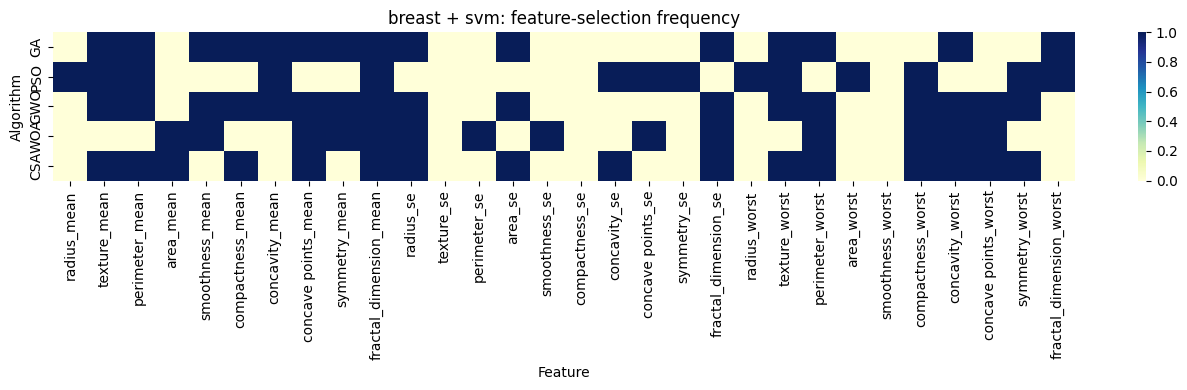

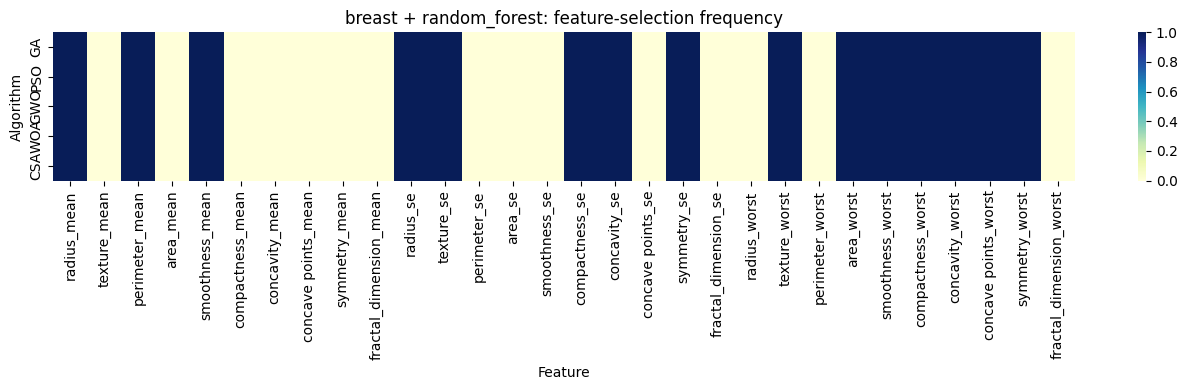

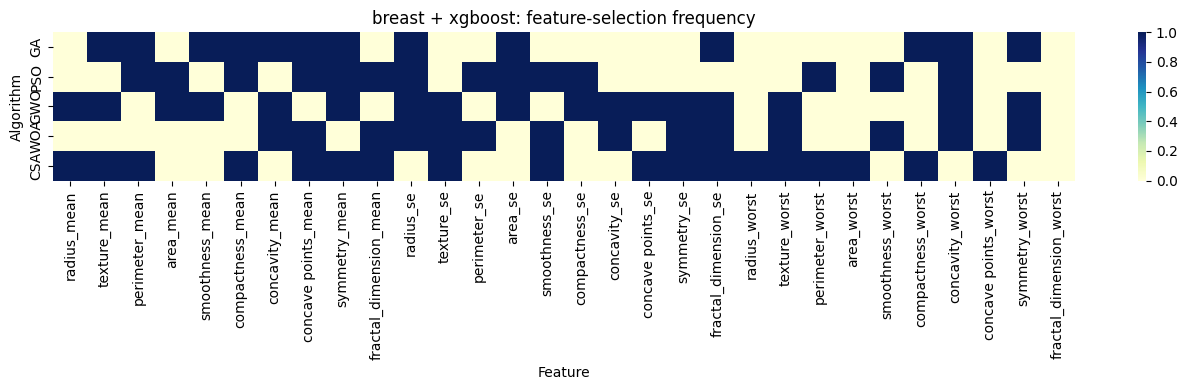

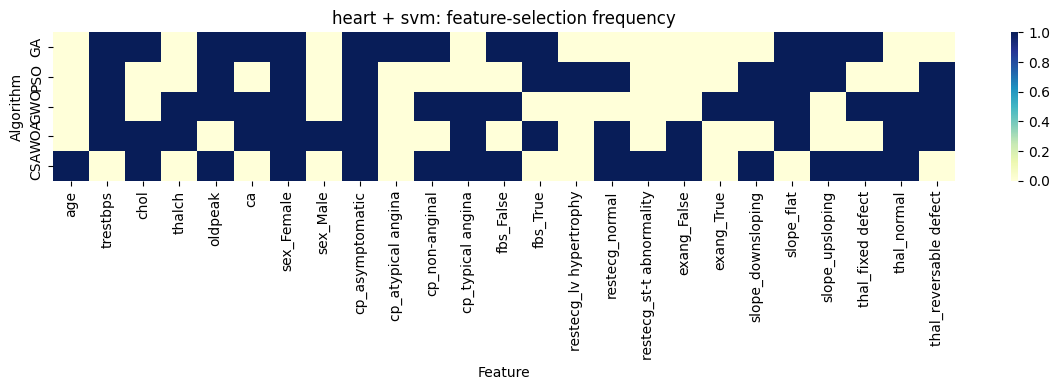

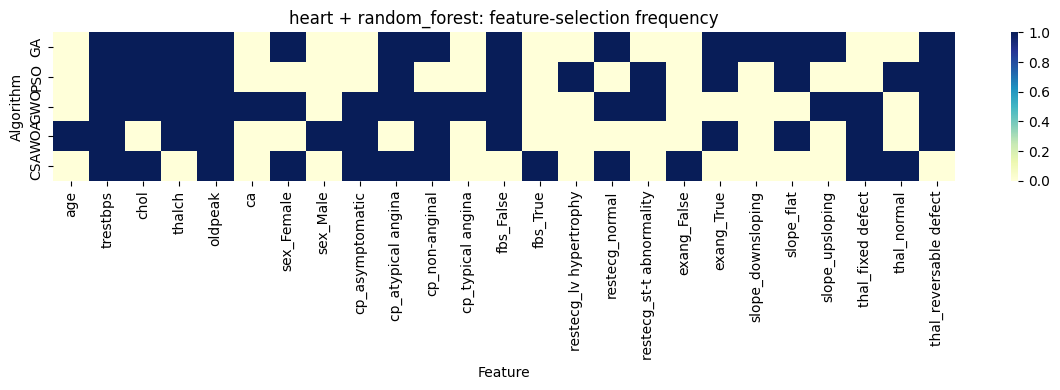

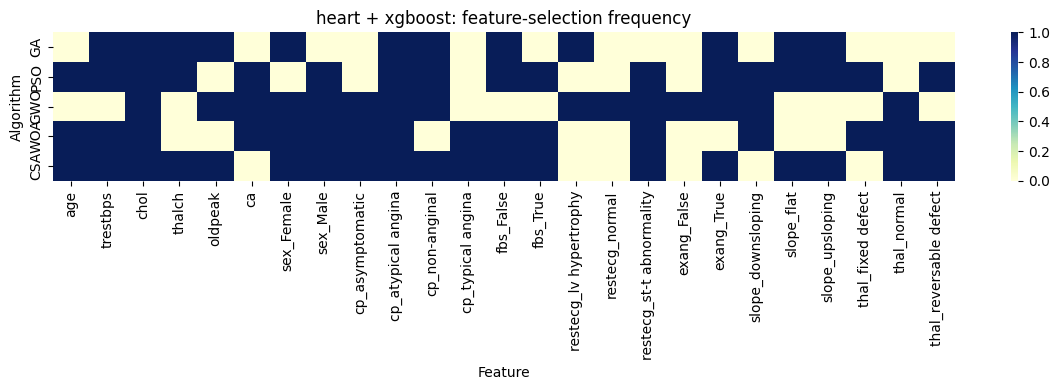

In [7]:
for dataset_name in DATASETS:
    feature_names = load_processed_data(
        dataset_name
    )[-1]

    for classifier_name in CLASSIFIERS:
        frequency_rows = {}

        for algorithm_name in optimizer_names:
            rows = all_results[
                (all_results["Dataset"] == dataset_name)
                & (
                    all_results["Classifier"]
                    == classifier_name
                )
                & (
                    all_results["Algorithm"]
                    == algorithm_name
                )
            ]

            masks = []

            for path_string in rows[
                "MaskFile"
            ].dropna():
                path = ROOT / path_string

                if path.exists():
                    masks.append(np.load(path))

            if masks:
                frequency_rows[algorithm_name] = (
                    np.vstack(masks).mean(axis=0)
                )

        if not frequency_rows:
            continue

        frequency_df = pd.DataFrame(
            frequency_rows,
            index=feature_names,
        ).T

        plt.figure(
            figsize=(max(12, len(feature_names) * 0.45), 4)
        )
        sns.heatmap(
            frequency_df,
            cmap="YlGnBu",
            vmin=0,
            vmax=1,
        )
        plt.xlabel("Feature")
        plt.ylabel("Algorithm")
        plt.title(
            f"{dataset_name} + {classifier_name}: "
            "feature-selection frequency"
        )
        plt.tight_layout()
        plt.savefig(
            PLOTS_DIR
            / (
                f"{dataset_name}_"
                f"{classifier_name}_feature_frequency.png"
            ),
            dpi=150,
        )
        plt.show()
